### Multivariate ChangePoint Detection

In [1]:
! pip install ruptures

  Using cached ruptures-1.1.7-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.1 MB)


In [2]:
from scipy.optimize import minimize
import ruptures as rpt
import matplotlib.pyplot as plt
import numpy as np

In [33]:
signal, bkps = rpt.pw_constant(500, 2,5, noise_std=1, delta=(1, 25))


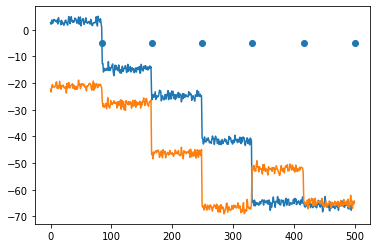

In [34]:
plt.plot(signal)
plt.scatter(bkps,-5*np.ones(len(bkps)))

In [35]:
y=signal[:,0]
z=signal[:,1]

### ChangePoint Detection as a LASSO Problem 

In [36]:
def compute_loss(mu,y,z,lam):
    term1= np.sum( (y-mu)**2)
   
    penalty=np.sum(np.diff(mu))
    return term1+abs(lam*penalty)

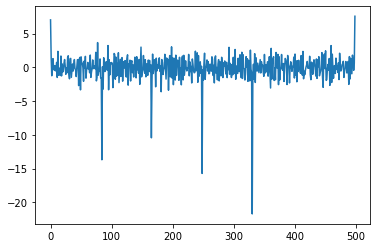

In [37]:
lam=15
opt=minimize(compute_loss,np.random.rand(500),args=(y,z,lam))

plt.plot(np.diff(opt.x))

In [54]:
np.sort(abs(np.diff(opt.x)))[-5:]

array([ 7.57061788, 10.43336325, 13.68547216, 15.70881635, 21.70349561])

In [62]:
cpd=np.where(np.diff(abs(opt.x))>np.sort(abs(np.diff(opt.x)))[-6])

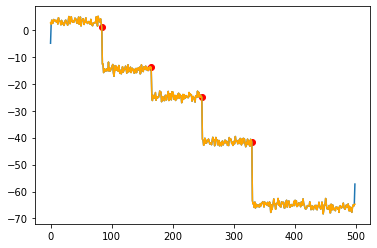

In [68]:
plt.plot(opt.x)
plt.plot(y,color='orange')
plt.scatter(cpd[0],opt.x[cpd],color='red')

In [65]:
cpd[0]

array([ 84, 165, 248, 330])

### Proposed Multivariate VAR Optimization Function which optimizes the piecewise constant signal of time series